In [1]:
import pandas as pd
import numpy as np
import oracledb
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

In [2]:
conn = oracledb.connect(user='pfe', password='pfe', dsn='127.0.0.1:1521/XEPDB1')
df = pd.read_sql('SELECT * FROM dataset_final1', conn)
conn.close()

C:\Users\fatimazahra\AppData\Local\Temp\ipykernel_11252\752863821.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM dataset_final1', conn)


In [3]:
df = df.drop(columns=[
    'LIBELLE_SECTEUR','LIBELLE_REGION','LIBELLE_VILLE',
    'TARGET_RECOUVREMENT','TARGET_POURCENTAGE_IMPAYE',
    'FLAG_GLOBAL','TARGET_RECOUVREMENT_NEW1',
    'TARGET_RECOUVREMENT_NEW2','TARGET_FLAG_CLEAN'
])

In [4]:
y = df["TARGET_POURCENTAGE_NEW1"]

X = df.drop(columns=["TARGET_POURCENTAGE_NEW1"])

In [5]:
# ================================
#  6. SPLIT PAR AFFILIÉS
# ================================
# On évite le data leakage en séparant par NUM_AFF

affilies = df["NUM_AFF"].unique()

# Mélange pour éviter biais
np.random.seed(42)
np.random.shuffle(affilies)

# Split fixe
train_aff = affilies[:130000]
test_aff  = affilies[130000:]

# Construction datasets
train_df = df[df["NUM_AFF"].isin(train_aff)].copy()
test_df  = df[df["NUM_AFF"].isin(test_aff)].copy()

print("Train affiliés:", train_df["NUM_AFF"].nunique())
print("Test affiliés:", test_df["NUM_AFF"].nunique())

# ================================
#  7. FEATURES / TARGET SPLIT
# ================================
y_train = train_df["TARGET_POURCENTAGE_NEW1"]
X_train = train_df.drop(columns=["TARGET_POURCENTAGE_NEW1"])

y_test = test_df["TARGET_POURCENTAGE_NEW1"]
X_test = test_df.drop(columns=["TARGET_POURCENTAGE_NEW1"])

Train affiliés: 130000
Test affiliés: 22834


In [6]:
X_train = X_train.select_dtypes(include=['int64','float64'])
X_test = X_test.select_dtypes(include=['int64','float64'])

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=533,
    max_depth=4,
    learning_rate=0.0205,
    subsample=0.704,
    colsample_bytree=0.782,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.782
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_me

In [9]:
y_pred = model.predict(X_test_scaled)

In [10]:
y_proba = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min())

In [11]:
X_test_df = test_df.copy()
X_test_df["proba_defaut"] = y_proba

In [12]:
X_test_df["score_metier"] = X_test_df["proba_defaut"] * 1000

In [13]:
def segment(score):
    if score <= 150:
        return "Faible"
    elif score <= 400:
        return "Modéré"
    elif score <= 700:
        return "Élevé"
    else:
        return "Très Élevé"

X_test_df["classe_risque"] = X_test_df["score_metier"].apply(segment)

classe_risque
Faible        15898
Très Élevé     2478
Élevé          2446
Modéré         2012
Name: count, dtype: int64


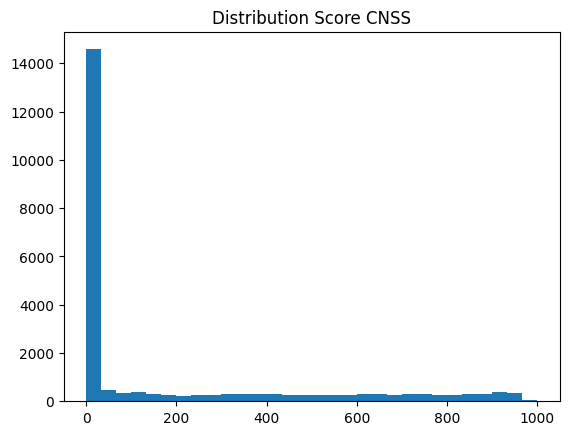

In [14]:
print(X_test_df["classe_risque"].value_counts())

import matplotlib.pyplot as plt

plt.hist(X_test_df["score_metier"], bins=30)
plt.title("Distribution Score CNSS")
plt.show()

classe_risque
Faible         0.546146
Modéré        20.100278
Très Élevé    62.146953
Élevé         40.835343
Name: y_true, dtype: float64


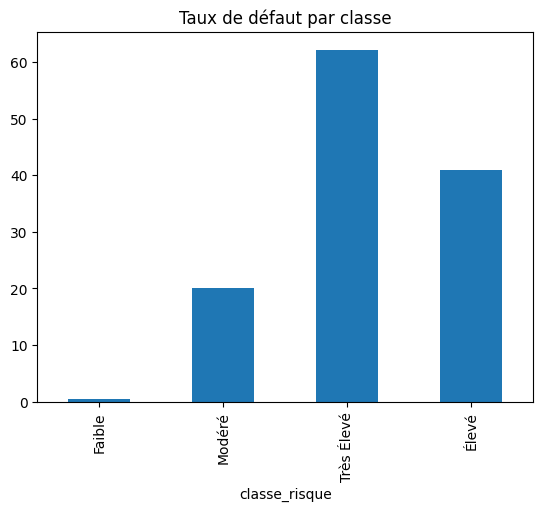

In [15]:
X_test_df["y_true"] = y_test.values

taux = X_test_df.groupby("classe_risque")["y_true"].mean()
print(taux)

taux.plot(kind="bar")
plt.title("Taux de défaut par classe")
plt.show()

In [16]:
taux_global = X_test_df["y_true"].mean()

top_20 = X_test_df.sort_values("proba_defaut", ascending=False).head(int(0.2 * len(X_test_df)))

taux_top20 = top_20["y_true"].mean()

print("Taux global:", taux_global)
print("Taux top 20%:", taux_top20)

Taux global: 13.270026714548482
Taux top 20%: 53.124572930354795


In [17]:
gain = (taux_top20 - taux_global) / taux_global * 100
print("Gain relatif (%) :", gain)

Gain relatif (%) : 300.33508653085164


In [18]:
def decision(p):
    if p > 0.7:
        return "REFUSER"
    elif p > 0.4:
        return "SURVEILLER"
    else:
        return "ACCEPTER"

X_test_df["decision"] = X_test_df["proba_defaut"].apply(decision)

print(X_test_df["decision"].value_counts())

decision
ACCEPTER      17910
REFUSER        2478
SURVEILLER     2446
Name: count, dtype: int64
